# Cover Categories Demo

Demonstrates the `cover_categories` function, which overlays WorldCover land cover types onto the tree categories.

## Setup

In [1]:
import rioxarray as rxr

from shelterbelts.utils.filepaths import get_filename
from shelterbelts.utils.visualisation import visualise_categories
from shelterbelts.indices.cover_categories import cover_categories, cover_categories_cmap, cover_categories_labels

# Example data
tree_file = get_filename('g2_26729_tree_categories.tif')
worldcover_file = get_filename('g2_26729_worldcover.tif')

## Default Parameters

In [2]:
ds = cover_categories(tree_file, worldcover_file)
ds

Saved: ./TEST_cover_categories.tif
Saved: ./TEST_cover_categories.png


<xarray.Dataset> Size: 44kB
Dimensions:           (x: 201, y: 201)
Coordinates:
  * x                 (x) float64 2kB 6.3e+05 6.3e+05 ... 6.32e+05 6.32e+05
  * y                 (y) float64 2kB 6.196e+06 6.196e+06 ... 6.194e+06
    spatial_ref       int64 8B 0
Data variables:
    cover_categories  (y, x) uint8 40kB 12 12 12 12 12 12 ... 30 30 30 30 30 30

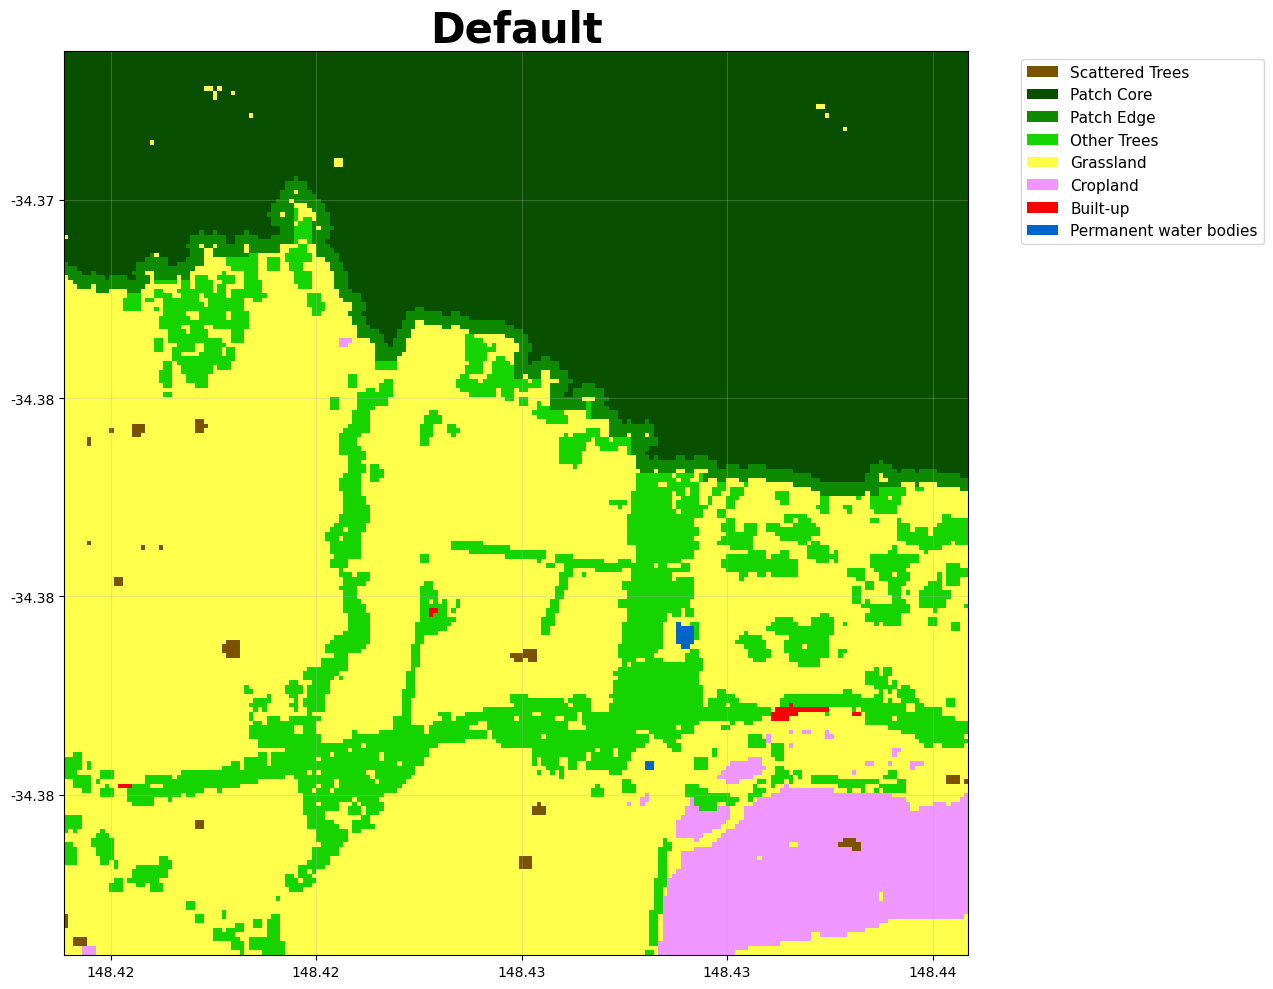

In [3]:
visualise_categories(
    ds['cover_categories'],
    colormap=cover_categories_cmap,
    labels=cover_categories_labels,
    title="Default"
)

## Using Datasets as input

Saved: ./TEST_cover_categories.tif
Saved: ./TEST_cover_categories.png


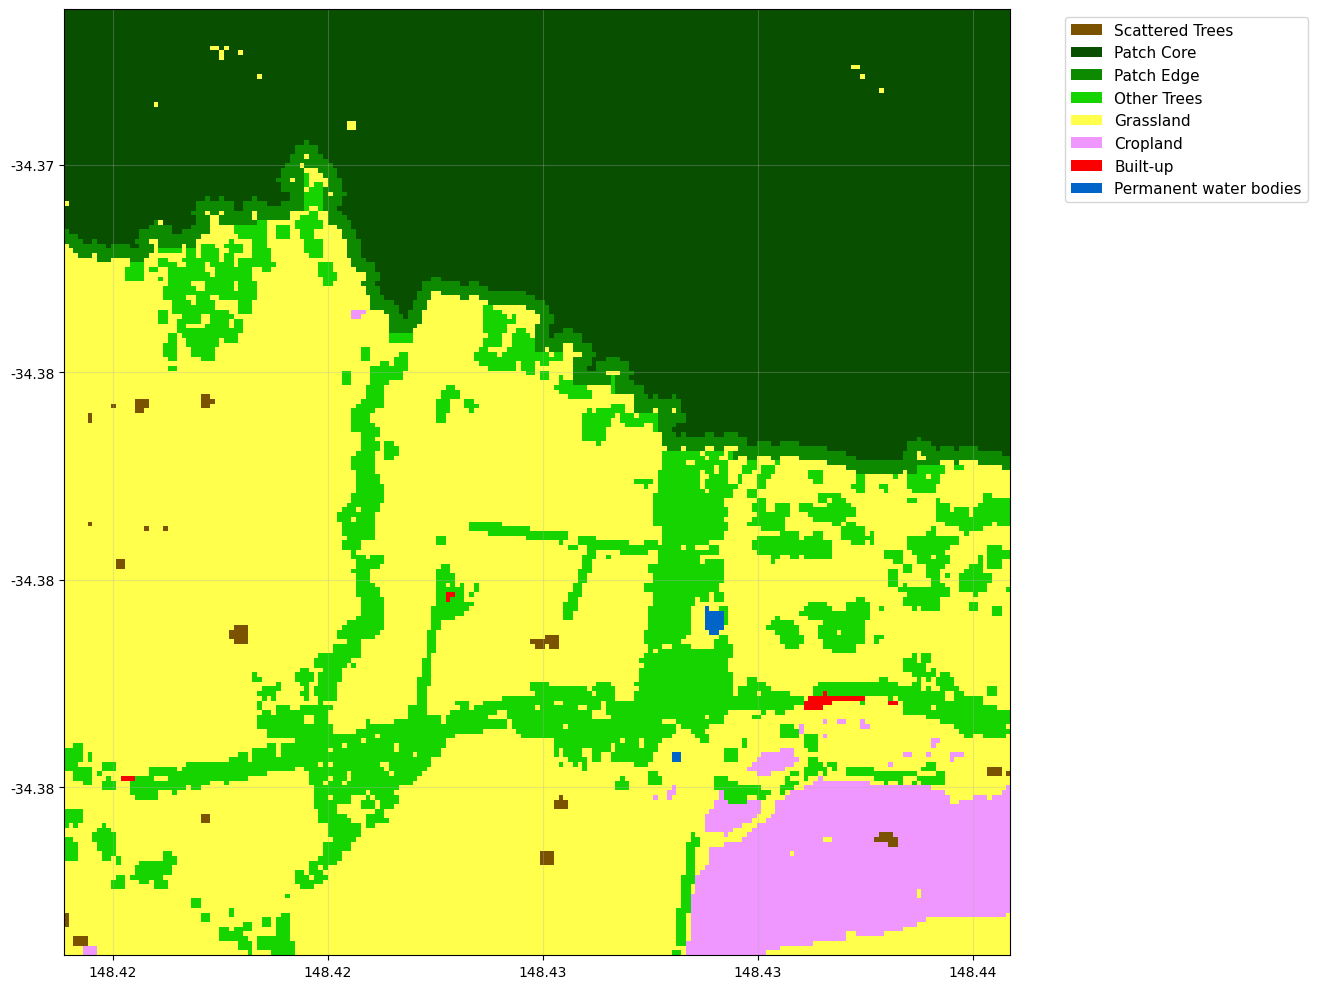

In [4]:
da_tree = rxr.open_rasterio(tree_file).squeeze('band').drop_vars('band')
da_worldcover = rxr.open_rasterio(worldcover_file).squeeze('band').drop_vars('band')

ds2 = cover_categories(da_tree, da_worldcover)
visualise_categories(
    ds2['cover_categories'],
    colormap=cover_categories_cmap,
    labels=cover_categories_labels
)

## Command Line Interface

In [5]:
!python -m shelterbelts.indices.cover_categories --help

usage: cover_categories.py [-h] [--outdir OUTDIR] [--stub STUB] [--no-savetif]
                           [--no-plot]
                           tree_data worldcover_data

positional arguments:
  tree_data        Integer tif file generated by tree_categories.py
  worldcover_data  Integer tif file generated by apis.worldcover.py

options:
  -h, --help       show this help message and exit
  --outdir OUTDIR  Output directory for saving results (default: current
                   directory)
  --stub STUB      Prefix for output filenames (default: TEST)
  --no-savetif     Disable saving GeoTIFF output (default: enabled)
  --no-plot        Disable PNG visualisation (default: enabled)


In [6]:
!python -m shelterbelts.indices.cover_categories {tree_file} {worldcover_file}

Saved: ./TEST_cover_categories.tif
Saved: ./TEST_cover_categories.png


### Cleanup
Remove the output files created by this notebook

In [7]:
# !rm *.tif
# !rm *.png
# !rm *.xml  # These get generated if you load the tifs in QGIS